# Data understanding
<div class="alert alert-info"> In this notebook, I practiced to explore the stock price data I downloaded from the Kaggle. </div> 

#### Credits and references
I would like to acknowledge the following resources referenced in this notebook:
<div style="margin:6px 0">
&#x1F331; "Stock Market Dataset": [Historical daily prices of Nasdaq-traded stocks and ETFs](https://www.kaggle.com/datasets/jacksoncrow/stock-market-dataset)</br>
<span style="background-color:LightCyan; margin-left:24px; padding-left:6px">Dataset info: The historic data is retrieved from Yahoo finance via yfinance python package.</span>
</div>
<div style="margin:6px 0">
&#x1F331; "Stock market data notebook" by Zainab El Sayed Taha: [Kaggle notebook](https://www.kaggle.com/code/zainabelsayedtaha/stock-market-data)</div>
<div style="margin:6px 0">
&#x1F331; "Stock market price prediction notebook" by Muhammad Ahsan: [Kaggle Public notebook](https://www.kaggle.com/code/ahsanneural/stock-market-price-direction-prediction)</div>
<div style="margin:6px 0">&#x1F331; Python for Finance Cookbook - Second Edition by Erik Lewinson, Packt Publishing</div>
&#x1F331; Machine Learning and Data Science Blueprints for Finance by Hariom Tatsat et al., O'reilly Media Inc. </div></br>

---  

<blockquote>
Yahoo!, Y!Finance, and Yahoo! finance are registered trademarks of Yahoo, Inc.
</blockquote>
</br>


In [1]:
base_dir = './yfinance_stock_data'

In [2]:
import pandas as pd

def import_data(file_path: str) -> pd.DataFrame:
    try:
        data = pd.read_csv(file_path)
        return data
    except Exception as e:
        print(f"An error occurred while importing data: {e}")
        return pd.DataFrame()

In [3]:
import os
apple_path = os.path.join(base_dir, 'AAPL.csv')
apple_stock = import_data(apple_path)
apple_stock.sample(n=5)

,Date,Open,High,Low,Close,Adj Close,Volume
8183,2013-05-24,62.978573,63.665714,62.908573,63.592857,56.386745,69041700
432,1982-08-31,0.321429,0.323661,0.321429,0.321429,0.254681,35140000
3302,1994-01-05,1.133929,1.209821,1.133929,1.205357,1.020083,153034000
6100,2005-02-14,5.909286,6.056428,5.860714,6.045000,5.247307,317865800
2915,1992-06-25,1.660714,1.660714,1.616071,1.629464,1.355649,40152000


In [4]:
apple_stock.describe()

,Open,High,Low,Close,Adj Close,Volume
count,9909.000000,9909.000000,9909.000000,9909.000000,9909.000000,9.909000e+03
mean,32.606849,32.936079,32.277560,32.618030,30.576570,8.582916e+07
std,58.415759,59.001576,57.883037,58.471899,56.746275,8.597195e+07
min,0.198661,0.198661,0.196429,0.196429,0.155638,3.472000e+05
25%,1.071429,1.089286,1.048571,1.071429,0.917643,3.304230e+07
50%,1.729286,1.758929,1.696429,1.732143,1.466154,5.766490e+07
75%,35.799999,36.265713,35.328571,35.761429,31.042374,1.069992e+08
max,324.739990,327.850006,323.350006,327.200012,327.200012,1.855410e+09


In [9]:
print("Data exploration...\n")
print("Data types:\n", apple_stock.dtypes)
print("\nMissing values:\n", apple_stock.isnull().sum())
print("\nShape of the dataset:", apple_stock.shape)
print("\n\U0001F4D2 Column names:", apple_stock.columns)
print("\n\U0001F4C5 Last date in the dataset:", apple_stock['Date'].max())

Data exploration...

Data types:
 Date             str
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

Missing values:
 Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Shape of the dataset: (9909, 7)

📒 Column names: Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='str')

📅 Last date in the dataset: 2020-04-01


In [11]:
apple_stock.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
9904,2020-03-26,246.520004,258.679993,246.360001,258.440002,258.440002,63021800
9905,2020-03-27,252.750000,255.869995,247.050003,247.740005,247.740005,51054200
9906,2020-03-30,250.740005,255.520004,249.399994,254.809998,254.809998,41994100
9907,2020-03-31,255.600006,262.489990,252.000000,254.289993,254.289993,49250500
9908,2020-04-01,246.500000,248.720001,239.130005,240.910004,240.910004,43956200


In [12]:
apple_stock['Date'] = pd.to_datetime(apple_stock['Date'])
print("\nData types after conversion:\n", apple_stock.dtypes)


Data types after conversion:
 Date         datetime64[us]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
dtype: object


In [14]:
apple_stock.sample(n=5)

,Date,Open,High,Low,Close,Adj Close,Volume
2791,1991-12-30,1.964286,2.044643,1.964286,2.026786,1.679669,45911600
7790,2011-10-28,57.571430,58.049999,57.501427,57.849998,50.216164,80710700
2223,1989-09-29,1.616071,1.625000,1.589286,1.589286,1.285681,17452400
4674,1999-06-14,1.660714,1.665179,1.611607,1.622768,1.408628,39270000
6270,2005-10-17,7.711429,7.747143,7.525714,7.634286,6.626871,154208600


In [ ]:
apple_stock

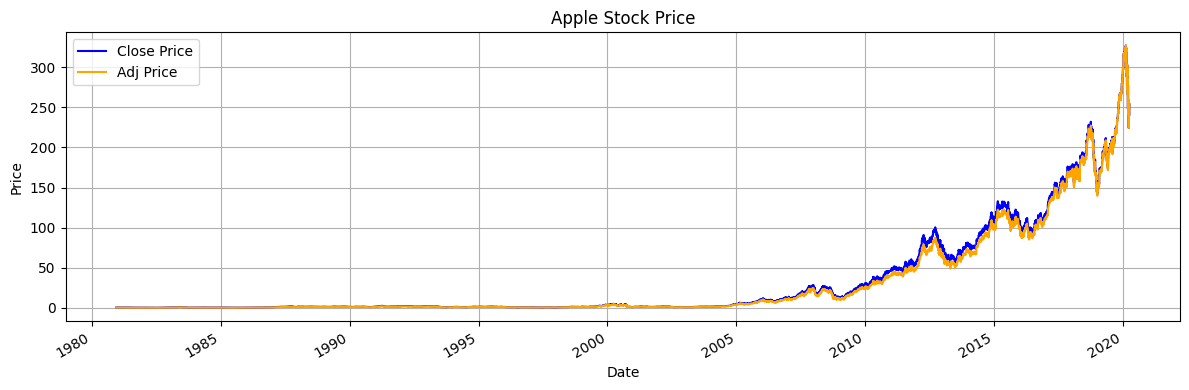

In [30]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 4))
apple_stock.plot(x='Date', y='Close', ax=ax, label='Close Price', color='blue')
apple_stock.plot(x='Date', y='Adj Close', ax=ax, label='Adj Price', color='orange')
ax.set_title("Apple Stock Price")
ax.set_xlabel("Date")
ax.set_ylabel("Price")

ax.grid(True)
fig.tight_layout()
plt.show()


In [31]:
# Feature engineering> Copied from Kaggle notebook. 
apple_stock['MA50'] = apple_stock['Close'].rolling(50).mean()
apple_stock['MA200'] = apple_stock['Close'].rolling(200).mean()
apple_stock['Previous day close price'] = apple_stock['Close'].shift(1)
apple_stock['Change in price'] = apple_stock['Close'] - apple_stock['Previous day close price']
apple_stock['Percent change in price'] = apple_stock['Close'].pct_change()

In [32]:
# I think it is better to using .diff()
apple_stock['Price diff'] = apple_stock['Close'].diff()

In [34]:
# Compare the 'Change in price' and 'Price diff' columns to confirm they are the same
comparison = apple_stock[['Change in price', 'Price diff']].dropna()
print(comparison.sample(n=5))

      Change in price  Price diff
1263         0.004464    0.004464
3283        -0.013393   -0.013393
6517        -0.117143   -0.117143
3737        -0.005022   -0.005022
9026         0.860001    0.860001


In [38]:
# Checking the duplicated rows just in case even though I don't expect it
duplicate_rows = apple_stock.duplicated().sum()
print(f"Duplicate rows: {duplicate_rows}")
if duplicate_rows > 0:
    apple_stock = apple_stock.drop_duplicates()
    print(f"Removed {duplicate_rows}")

Duplicate rows: 0


In [ ]:
# Copied from Kaggle notebook to verify the dataset (I referred the link on top of the notebook)
# 4. Verify data integrity
print("\n🔍 Data Integrity Check:")
print(f"   • No negative prices: {(apple_stock[['Open', 'High', 'Low', 'Close']] >= 0).all().all()}")
print(f"   • High >= Low: {(apple_stock['High'] >= apple_stock['Low']).all()}")
print(f"   • No zero volume days: {(apple_stock['Volume'] > 0).all()}")


🔍 Data Integrity Check:
   • No negative prices: True
   • High >= Low: True
   • No zero volume days: True


The following cells are copied from Kaggle notebook created by Muhammad Ahsan (the link referred at top). Although I am planning to use "ta" library, I liked the calculations he made using pandas. 

In [ ]:
import numpy as np
print("Starting Feature Engineering...")
print("="*60)

# 1. Daily Returns
apple_stock['Daily_Return'] = apple_stock['Close'].pct_change() * 100
print("✅ Daily Returns calculated")

# 2. Moving Averages (Simple MA)
apple_stock['MA_7'] = apple_stock['Close'].rolling(window=7).mean()
apple_stock['MA_21'] = apple_stock['Close'].rolling(window=21).mean()
apple_stock['MA_50'] = apple_stock['Close'].rolling(window=50).mean()
print("✅ Moving Averages (7, 21, 50) calculated")

# 3. Exponential Moving Averages
apple_stock['EMA_12'] = apple_stock['Close'].ewm(span=12, adjust=False).mean()
apple_stock['EMA_26'] = apple_stock['Close'].ewm(span=26, adjust=False).mean()
print("✅ Exponential Moving Averages (12, 26) calculated")

# 4. MACD (Moving Average Convergence Divergence)
apple_stock['MACD'] = apple_stock['EMA_12'] - apple_stock['EMA_26']
apple_stock['Signal_Line'] = apple_stock['MACD'].ewm(span=9, adjust=False).mean()
apple_stock['MACD_Histogram'] = apple_stock['MACD'] - apple_stock['Signal_Line']
print("✅ MACD indicators calculated")

# 5. Bollinger Bands
apple_stock['BB_Middle'] = apple_stock['Close'].rolling(window=20).mean()
apple_stock['BB_Std'] = apple_stock['Close'].rolling(window=20).std()
apple_stock['BB_Upper'] = apple_stock['BB_Middle'] + (2 * apple_stock['BB_Std'])
apple_stock['BB_Lower'] = apple_stock['BB_Middle'] - (2 * apple_stock['BB_Std'])
apple_stock['BB_Width'] = apple_stock['BB_Upper'] - apple_stock['BB_Lower']
print("✅ Bollinger Bands calculated")

# 6. RSI (Relative Strength Index)
delta = apple_stock['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
apple_stock['RSI'] = 100 - (100 / (1 + rs))
print("✅ RSI (Relative Strength Index) calculated")

# 7. Volatility (21-day rolling standard deviation of returns)
apple_stock['Volatility'] = apple_stock['Daily_Return'].rolling(window=21).std()
print("✅ Volatility calculated")

# 8. Volume Indicators
apple_stock['Volume_MA_7'] = apple_stock['Volume'].rolling(window=7).mean()
apple_stock['Volume_Change'] = apple_stock['Volume'].pct_change() * 100
print("✅ Volume indicators calculated")

# 9. Price Range Features
apple_stock['Price_Range'] = apple_stock['High'] - apple_stock['Low']
apple_stock['Price_Range_Pct'] = (apple_stock['Price_Range'] / apple_stock['Close']) * 100
print("✅ Price range features calculated")

# 10. Target Variable: Next Day Price Direction
apple_stock['Next_Day_Close'] = apple_stock['Close'].shift(-1)
apple_stock['Price_Change'] = apple_stock['Next_Day_Close'] - apple_stock['Close']
apple_stock['Price_Change_Pct'] = (apple_stock['Price_Change'] / apple_stock['Close']) * 100

# Create target with threshold (±0.5% for neutral zone)
threshold = 0.5
apple_stock['Target'] = pd.cut(apple_stock['Price_Change_Pct'], 
                       bins=[-np.inf, -threshold, threshold, np.inf],
                       labels=['Down', 'Neutral', 'Up'])

print("✅ Target variable (Price Direction) created")

# 11. Remove NaN values created by rolling windows and shifting
df_clean = apple_stock.dropna().reset_index(drop=True)

print("\n" + "="*60)
print("📊 FEATURE ENGINEERING SUMMARY")
print("="*60)
print(f"Original dataset: {len(apple_stock)} rows")
print(f"After removing NaNs: {len(df_clean)} rows")
print(f"Total features created: {len(df_clean.columns) - 7}")  # Minus original columns

print("\n🎯 Target Distribution:")
target_counts = df_clean['Target'].value_counts()
for label, count in target_counts.items():
    percentage = (count / len(df_clean)) * 100
    print(f"   • {label}: {count} days ({percentage:.1f}%)")

print("\n📊 Feature Summary Statistics:")
feature_stats = df_clean[['Daily_Return', 'RSI', 'MACD', 'Volatility', 'BB_Width']].describe()
print(feature_stats)

print("\n✅ Feature engineering completed successfully!")

# Display sample with new features
print("\n🔍 Sample Data with Features:")
display_cols = ['Date', 'Close', 'Daily_Return', 'MA_7', 'MA_21', 'RSI', 'MACD', 'Target']
print(df_clean[display_cols].tail(10))

⚙️ Starting Feature Engineering...
✅ Daily Returns calculated
✅ Moving Averages (7, 21, 50) calculated
✅ Exponential Moving Averages (12, 26) calculated
✅ MACD indicators calculated
✅ Bollinger Bands calculated
✅ RSI (Relative Strength Index) calculated
✅ Volatility calculated
✅ Volume indicators calculated
✅ Price range features calculated
✅ Target variable (Price Direction) created

📊 FEATURE ENGINEERING SUMMARY
Original dataset: 9909 rows
After removing NaNs: 9709 rows
Total features created: 30

🎯 Target Distribution:
   • Up: 4018 days (41.4%)
   • Down: 3738 days (38.5%)
   • Neutral: 1953 days (20.1%)

📊 Feature Summary Statistics:
       Daily_Return          RSI         MACD   Volatility     BB_Width
count   9709.000000  9709.000000  9709.000000  9709.000000  9709.000000
mean       0.112695    53.236627     0.197432     2.557526     3.953556
std        2.859237    17.477253     1.502212     1.271977     7.965402
min      -51.869158     2.898540   -18.660071     0.456565     0.

📈 Creating Time Series Visualizations...


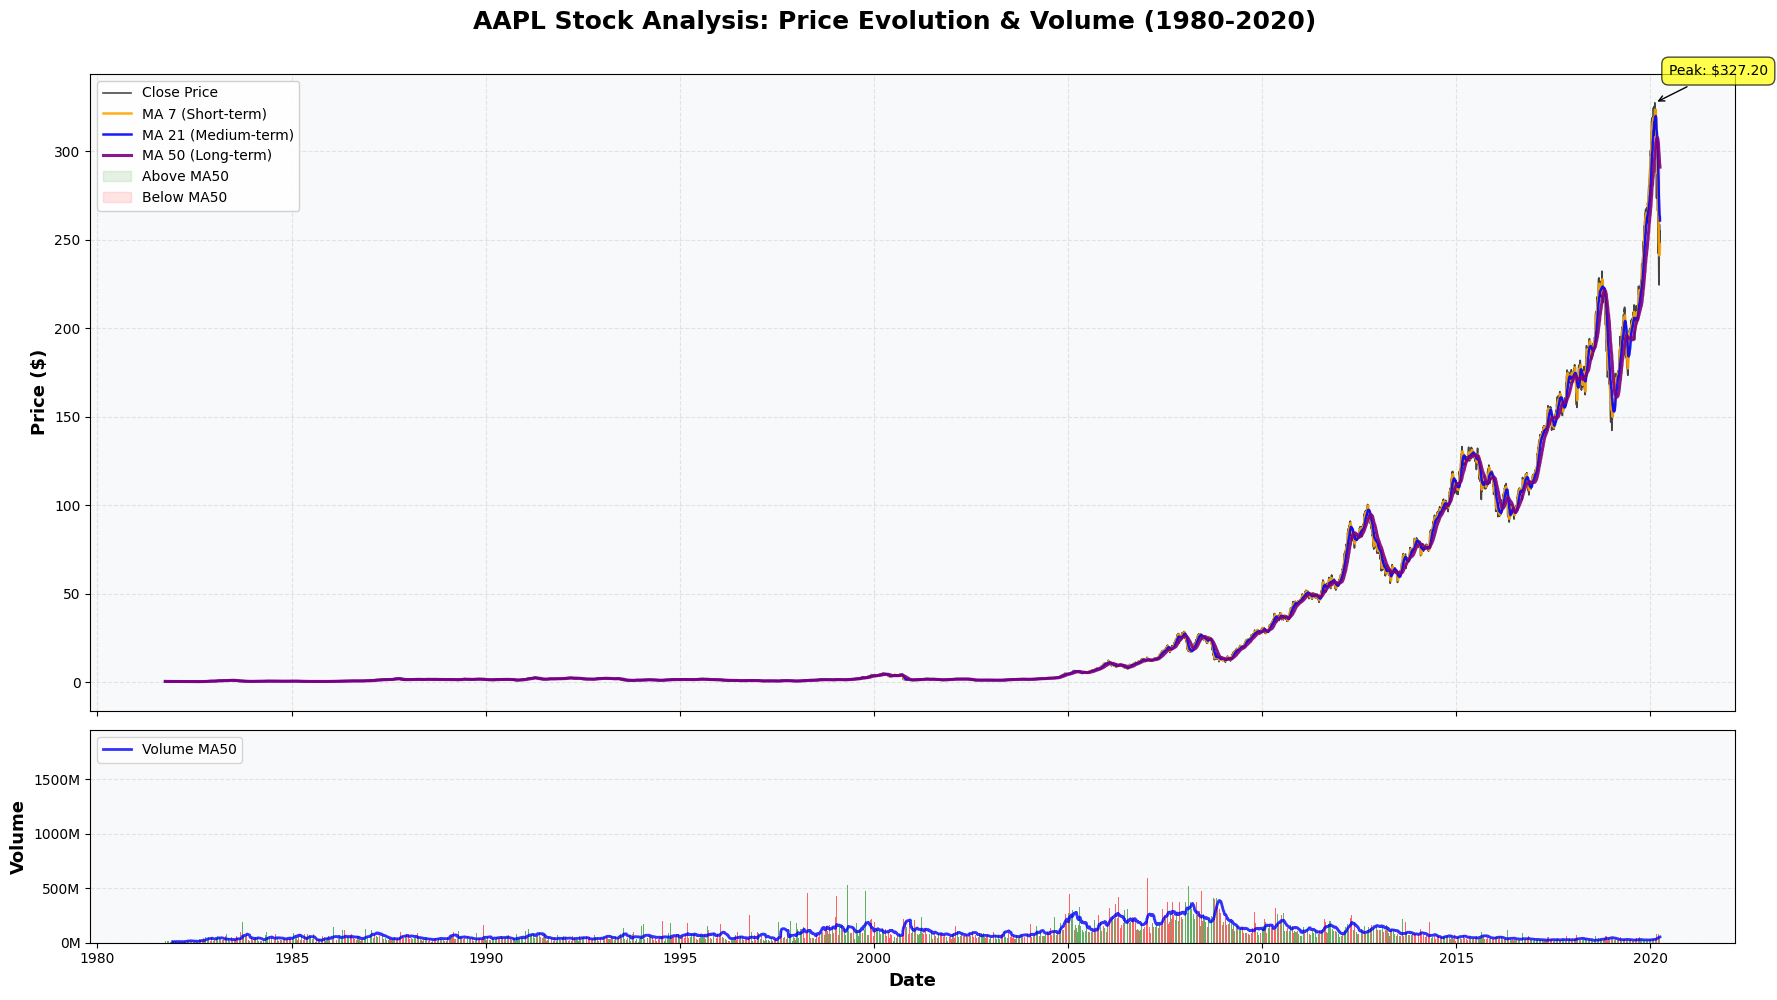

✅ Price and Volume visualization created!

💡 Key Insights from the Chart:
📈 Price Journey:
   • Starting price (1980): $0.27
   • Ending price (2020): $254.29
   • All-time high: $327.20 on 2020-02-12
   • Total return: 94050.3%

📊 Volume Analysis:
   • Average daily volume: 87,415,789
   • Highest volume: 1,855,410,200 on 2000-09-29

📉 Moving Averages Insights:
   • MA7 (current): $247.44
   • MA21 (current): $260.71
   • MA50 (current): $290.88


In [ ]:
print("📈 Creating Time Series Visualizations...")
print("="*60)

# Create figure with subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), 
                                gridspec_kw={'height_ratios': [3, 1]},
                                sharex=True)

fig.suptitle('AAPL Stock Analysis: Price Evolution & Volume (1980-2020)', 
             fontsize=18, fontweight='bold', y=0.995)

# ==========================================
# SUBPLOT 1: Price with Moving Averages
# ==========================================

# Plot closing price
ax1.plot(df_clean['Date'], df_clean['Close'], 
         label='Close Price', color='black', linewidth=1.2, alpha=0.7)

# Plot moving averages
ax1.plot(df_clean['Date'], df_clean['MA_7'], 
         label='MA 7 (Short-term)', color='orange', linewidth=1.8, alpha=0.9)

ax1.plot(df_clean['Date'], df_clean['MA_21'], 
         label='MA 21 (Medium-term)', color='blue', linewidth=1.8, alpha=0.9)

ax1.plot(df_clean['Date'], df_clean['MA_50'], 
         label='MA 50 (Long-term)', color='purple', linewidth=2.2, alpha=0.9)

# Fill area between price and MA_50 to show divergence
ax1.fill_between(df_clean['Date'], df_clean['Close'], df_clean['MA_50'], 
                  where=(df_clean['Close'] >= df_clean['MA_50']), 
                  color='green', alpha=0.1, label='Above MA50')
ax1.fill_between(df_clean['Date'], df_clean['Close'], df_clean['MA_50'], 
                  where=(df_clean['Close'] < df_clean['MA_50']), 
                  color='red', alpha=0.1, label='Below MA50')

# Styling
ax1.set_ylabel('Price ($)', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_facecolor('#f8f9fa')

# Add annotations for key milestones
max_price_idx = df_clean['Close'].idxmax()
ax1.annotate(f'Peak: ${df_clean.loc[max_price_idx, "Close"]:.2f}',
             xy=(df_clean.loc[max_price_idx, 'Date'], df_clean.loc[max_price_idx, 'Close']),
             xytext=(10, 20), textcoords='offset points',
             bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.7),
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

# ==========================================
# SUBPLOT 2: Trading Volume
# ==========================================

# Color volume bars based on price movement
colors = ['green' if close >= open_price else 'red' 
          for close, open_price in zip(df_clean['Close'], df_clean['Open'])]

ax2.bar(df_clean['Date'], df_clean['Volume'], 
        color=colors, alpha=0.6, width=1, edgecolor='none')

# Add volume moving average
volume_ma = df_clean['Volume'].rolling(window=50).mean()
ax2.plot(df_clean['Date'], volume_ma, 
         color='blue', linewidth=2, label='Volume MA50', alpha=0.8)

# Styling
ax2.set_xlabel('Date', fontsize=13, fontweight='bold')
ax2.set_ylabel('Volume', fontsize=13, fontweight='bold')
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(True, alpha=0.3, axis='y', linestyle='--')
ax2.set_facecolor('#f8f9fa')

# Format y-axis for volume (show in millions)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1e6)}M'))

plt.tight_layout()
plt.show()

print("✅ Price and Volume visualization created!")

# Key insights
print("\n💡 Key Insights from the Chart:")
print("="*60)
print("📈 Price Journey:")
print(f"   • Starting price (1980): ${df_clean['Close'].iloc[0]:.2f}")
print(f"   • Ending price (2020): ${df_clean['Close'].iloc[-1]:.2f}")
print(f"   • All-time high: ${df_clean['Close'].max():.2f} on {df_clean.loc[df_clean['Close'].idxmax(), 'Date'].date()}")
print(f"   • Total return: {((df_clean['Close'].iloc[-1] / df_clean['Close'].iloc[0]) - 1) * 100:.1f}%")

print("\n📊 Volume Analysis:")
print(f"   • Average daily volume: {df_clean['Volume'].mean():,.0f}")
print(f"   • Highest volume: {df_clean['Volume'].max():,.0f} on {df_clean.loc[df_clean['Volume'].idxmax(), 'Date'].date()}")

print("\n📉 Moving Averages Insights:")
print(f"   • MA7 (current): ${df_clean['MA_7'].iloc[-1]:.2f}")
print(f"   • MA21 (current): ${df_clean['MA_21'].iloc[-1]:.2f}")
print(f"   • MA50 (current): ${df_clean['MA_50'].iloc[-1]:.2f}")

🔍 Creating Pattern Discovery Visualizations...


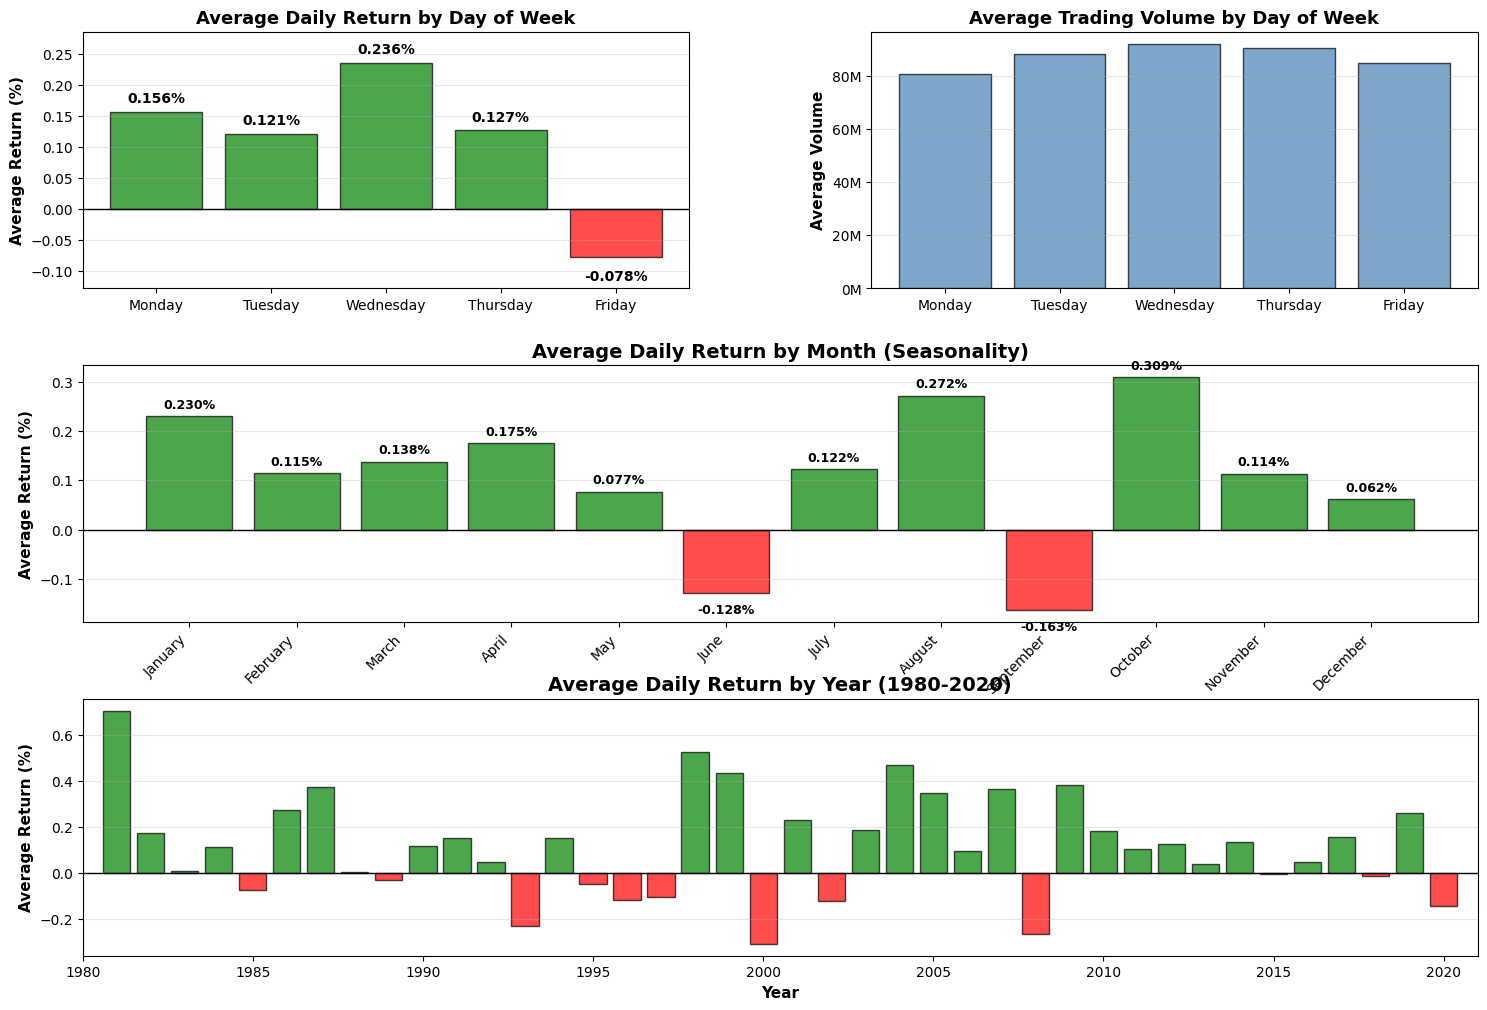

✅ Pattern discovery visualizations created!

💡 Pattern Discovery Insights:
📅 Day of Week Analysis:
   • Best performing day: Wednesday (0.236%)
   • Worst performing day: Friday (-0.078%)
   • Highest volume day: Wednesday (92,099,273)
   • Lowest volume day: Monday (80,886,976)

📆 Monthly Seasonality:
   • Best performing month: October (0.309%)
   • Worst performing month: September (-0.163%)
   • Positive months: 10/12
   • Negative months: 2/12

📊 Yearly Performance:
   • Best year: 1981 (0.706%)
   • Worst year: 2000 (-0.309%)
   • Positive years: 28/40 (70.0%)
   • Negative years: 12/40 (30.0%)

🎯 Performance by Decade:
   • 1980s: 0.125% average daily return
   • 1990s: 0.092% average daily return
   • 2000s: 0.138% average daily return
   • 2010s: 0.104% average daily return
   • 2020s: -0.146% average daily return

✅ Pattern discovery analysis completed!


In [49]:
df_clean['Year'] = df_clean['Date'].dt.year
df_clean['Month'] = df_clean['Date'].dt.month
df_clean['Day'] = df_clean['Date'].dt.day
df_clean['Day_of_Week'] = df_clean['Date'].dt.dayofweek

print("🔍 Creating Pattern Discovery Visualizations...")
print("="*60)

# Create figure with multiple subplots
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# ==========================================
# 1. Average Return by Day of Week
# ==========================================

ax1 = fig.add_subplot(gs[0, 0])

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
df_clean['Day_Name'] = df_clean['Date'].dt.day_name()
day_returns = df_clean.groupby('Day_Name')['Daily_Return'].mean().reindex(day_order)

colors_day = ['green' if x > 0 else 'red' for x in day_returns]
bars = ax1.bar(day_returns.index, day_returns.values, color=colors_day, alpha=0.7, edgecolor='black')

# Add value labels
for bar, val in zip(bars, day_returns.values):
    ax1.text(bar.get_x() + bar.get_width()/2., val + (0.01 if val > 0 else -0.02),
             f'{val:.3f}%', ha='center', va='bottom' if val > 0 else 'top',
             fontsize=10, fontweight='bold')

ax1.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax1.set_title('Average Daily Return by Day of Week', fontsize=13, fontweight='bold')
ax1.set_ylabel('Average Return (%)', fontsize=11, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(min(day_returns) - 0.05, max(day_returns) + 0.05)

# ==========================================
# 2. Average Volume by Day of Week
# ==========================================

ax2 = fig.add_subplot(gs[0, 1])

day_volume = df_clean.groupby('Day_Name')['Volume'].mean().reindex(day_order)

bars_vol = ax2.bar(day_volume.index, day_volume.values, color='steelblue', alpha=0.7, edgecolor='black')

ax2.set_title('Average Trading Volume by Day of Week', fontsize=13, fontweight='bold')
ax2.set_ylabel('Average Volume', fontsize=11, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1e6)}M'))

# ==========================================
# 3. Monthly Seasonality
# ==========================================

ax3 = fig.add_subplot(gs[1, :])

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
df_clean['Month_Name'] = df_clean['Date'].dt.month_name()
monthly_returns = df_clean.groupby('Month_Name')['Daily_Return'].mean().reindex(month_order)

colors_month = ['green' if x > 0 else 'red' for x in monthly_returns]
bars_month = ax3.bar(monthly_returns.index, monthly_returns.values, color=colors_month, 
                     alpha=0.7, edgecolor='black')

# Add value labels
for bar, val in zip(bars_month, monthly_returns.values):
    ax3.text(bar.get_x() + bar.get_width()/2., val + (0.01 if val > 0 else -0.02),
             f'{val:.3f}%', ha='center', va='bottom' if val > 0 else 'top',
             fontsize=9, fontweight='bold', rotation=0)

ax3.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax3.set_title('Average Daily Return by Month (Seasonality)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Month', fontsize=11, fontweight='bold')
ax3.set_ylabel('Average Return (%)', fontsize=11, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

# ==========================================
# 4. Yearly Performance
# ==========================================

ax4 = fig.add_subplot(gs[2, :])

yearly_returns = df_clean.groupby('Year')['Daily_Return'].mean()

colors_year = ['green' if x > 0 else 'red' for x in yearly_returns]
bars_year = ax4.bar(yearly_returns.index, yearly_returns.values, color=colors_year, 
                    alpha=0.7, edgecolor='black', width=0.8)

ax4.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax4.set_title('Average Daily Return by Year (1980-2020)', fontsize=14, fontweight='bold')
ax4.set_xlabel('Year', fontsize=11, fontweight='bold')
ax4.set_ylabel('Average Return (%)', fontsize=11, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)
ax4.set_xlim(yearly_returns.index.min() - 1, yearly_returns.index.max() + 1)

# fig.tight_layout()
plt.show()

print("✅ Pattern discovery visualizations created!")

# Statistical Analysis
print("\n💡 Pattern Discovery Insights:")
print("="*60)

# Day of week analysis
print("📅 Day of Week Analysis:")
best_day = day_returns.idxmax()
worst_day = day_returns.idxmin()
print(f"   • Best performing day: {best_day} ({day_returns[best_day]:.3f}%)")
print(f"   • Worst performing day: {worst_day} ({day_returns[worst_day]:.3f}%)")
print(f"   • Highest volume day: {day_volume.idxmax()} ({day_volume.max():,.0f})")
print(f"   • Lowest volume day: {day_volume.idxmin()} ({day_volume.min():,.0f})")

# Monthly seasonality
print("\n📆 Monthly Seasonality:")
best_month = monthly_returns.idxmax()
worst_month = monthly_returns.idxmin()
print(f"   • Best performing month: {best_month} ({monthly_returns[best_month]:.3f}%)")
print(f"   • Worst performing month: {worst_month} ({monthly_returns[worst_month]:.3f}%)")

positive_months = (monthly_returns > 0).sum()
print(f"   • Positive months: {positive_months}/12")
print(f"   • Negative months: {12 - positive_months}/12")

# Yearly trends
print("\n📊 Yearly Performance:")
best_year = yearly_returns.idxmax()
worst_year = yearly_returns.idxmin()
print(f"   • Best year: {best_year} ({yearly_returns[best_year]:.3f}%)")
print(f"   • Worst year: {worst_year} ({yearly_returns[worst_year]:.3f}%)")

positive_years = (yearly_returns > 0).sum()
total_years = len(yearly_returns)
print(f"   • Positive years: {positive_years}/{total_years} ({positive_years/total_years*100:.1f}%)")
print(f"   • Negative years: {total_years - positive_years}/{total_years} ({(total_years - positive_years)/total_years*100:.1f}%)")

# Decade analysis
df_clean['Decade'] = (df_clean['Year'] // 10) * 10
decade_returns = df_clean.groupby('Decade')['Daily_Return'].mean()

print("\n🎯 Performance by Decade:")
for decade, ret in decade_returns.items():
    print(f"   • {decade}s: {ret:.3f}% average daily return")

print("\n✅ Pattern discovery analysis completed!")


## Conclusion 

🍋 Experimented the exploratory data analysis by referring to the public notebooks. 

|Date (YYYY-MM-DD)|Version|Created By|  
|--|--|--|
|2026-02-26|1.0|Battogtokh Baasanjav|